# Data Preparation and EDA

This notebook covers:
- Data understanding (basic inspection)
- Data aggregation for monthly EV sales
- EDA, decomposition, and outlier checks

In [91]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8")

In [92]:
df_raw = pd.read_csv("../Data/Raw/China Automobile Sales Data.csv")
df_raw.head()

,model,units_sold,make,low_price,high_price,year_month,is_ev,body_type,brand,brand_country
0,Model Y,69098,特斯拉中国,316.9,417.9,2022-11-01,EV,SUV,Tesla,United States
1,宏光MINIEV,68567,上汽通用五菱,32.8,99.9,2022-11-01,EV,Hatchback,Wuling Motors,China
2,宋PLUS新能源,64145,比亚迪,152.8,216.8,2022-11-01,EV,SUV,BYD,China
3,汉,31786,比亚迪,214.8,329.8,2022-11-01,EV,Sedan,BYD,China
4,Model 3,31193,特斯拉中国,266.7,339.9,2022-11-01,EV,Sedan,Tesla,United States


We only need to focus on three columns: `units_sold`, `year_month`, and `is_ev`.
* `units_sold`: total units of each model sold in one month
* `year_month`: the recorded year and month
* `is_ev`: indicates whether the model is an EV or gasoline vehicle

In [93]:
df_raw.info()
df_raw.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38806 entries, 0 to 38805
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   model          38806 non-null  object 
 1   units_sold     38806 non-null  int64  
 2   make           38806 non-null  object 
 3   low_price      38806 non-null  float64
 4   high_price     38806 non-null  float64
 5   year_month     38806 non-null  object 
 6   is_ev          38806 non-null  object 
 7   body_type      36440 non-null  object 
 8   brand          38806 non-null  object 
 9   brand_country  38806 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 3.0+ MB


model               0
units_sold          0
make                0
low_price           0
high_price          0
year_month          0
is_ev               0
body_type        2366
brand               0
brand_country       0
dtype: int64

* Dataset has 38806 rows and 10 columns
* `body type` has 2366 missing values, but no handling is needed because that column is not used

In [94]:
df_raw[df_raw.duplicated()].head()

,model,units_sold,make,low_price,high_price,year_month,is_ev,body_type,brand,brand_country
3260,东南DX7,1,东南汽车,99.9,139.9,2023-04-01,Gasoline,SUV,Southeast,China
3261,冒险家新能源,1,长安林肯,309.8,345.8,2023-04-01,EV,SUV,Lincoln,United States
5404,沃尔沃S60新能源,38,沃尔沃亚太,399.9,461.9,2023-08-01,EV,Sedan,Volvo,Sweden
6002,奥迪A6L新能源,3,一汽-大众奥迪,508.0,508.0,2023-09-01,EV,Sedan,Audi,Germany
6956,蔚来EC7,350,蔚来,458.0,548.0,2023-11-01,EV,NaN,NIO,China


In [95]:
df_raw = df_raw.drop_duplicates()

A total of 33 fully duplicated observations were identified and removed to prevent double counting during monthly aggregation

In [96]:
df_raw["units_sold"] = (
    df_raw["units_sold"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df_raw["units_sold"] = pd.to_numeric(df_raw["units_sold"], errors="coerce")

print("Missing units_sold after convert:", df_raw["units_sold"].isna().sum())
print("Negative units_sold:", (df_raw["units_sold"] < 0).sum())

Missing units_sold after convert: 0
Negative units_sold: 0


In [97]:
df_raw['units_sold'].describe()

count    38773.000000
mean      3529.806051
std       5884.277544
min          1.000000
25%        259.000000
50%       1219.000000
75%       4106.000000
max      73009.000000
Name: units_sold, dtype: float64

Based on the descriptive statistics results, `units_sold` contains reasonable positive values (`Min >= 1`). Although the maximum values are large, they realistically reflect the best-selling vehicle models in the market. Therefore, no data entry errors were identified, and 100% of the raw data was preserved for the aggregation step.

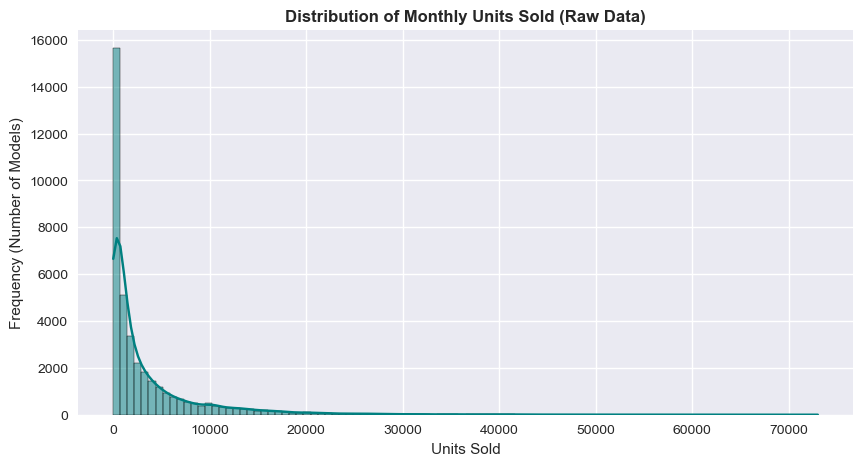

In [98]:
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['units_sold'], bins=100, kde=True, color='teal')
plt.title('Distribution of Monthly Units Sold (Raw Data)', fontweight='bold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency (Number of Models)')
plt.show()

The distribution of the original data is clearly right-skewed, accurately reflecting the Pareto principle in the automotive market: a small number of popular vehicle models account for the majority of total market sales

## Aggregate monthly EV sales

In [99]:
df_raw['is_ev'].value_counts()

is_ev
Gasoline    30258
EV           8515
Name: count, dtype: int64

In [100]:
df = df_raw.copy()
df["year_month"] = pd.to_datetime(df["year_month"], errors="coerce")
df = df.dropna(subset=["year_month"])

# Aggregate monthly data
total_sales = df.groupby("year_month")["units_sold"].sum()
ev_sales = df[df["is_ev"] == "EV"].groupby("year_month")["units_sold"].sum()

monthly = pd.concat([ev_sales, total_sales], axis=1)
monthly.columns = ["EV_Sales", "Total_Sales"]

# Force indexing by monthly frequency (month start)
monthly = monthly.asfreq("MS")

monthly["EV_Sales"] = monthly["EV_Sales"].fillna(0)
monthly["Total_Sales"] = monthly["Total_Sales"].fillna(0)

monthly

,EV_Sales,Total_Sales
year_month,,
2018-01-01,24480,2436495
2018-02-01,23449,1469679
2018-03-01,42745,2144088
2018-04-01,51110,1881043
2018-05-01,60565,1887345
...,...,...
2023-12-01,755943,2360143
2024-01-01,489514,2034527
2024-02-01,290125,1111515


The `EV_Sales` series shows a very strong and clearly defined upward trend over the long term. In the early months of 2018, electric vehicle sales were still quite limited, fluctuating between **23,000 and 60,000 vehicles per month**. However, by late 2023 to early 2024, the figures had increased exponentially, peaking at **755,943 vehicles** (in December 2023) and remaining relatively stable at an average level of around **400,000–500,000 vehicles per month**.

In [101]:
monthly['EV_Sales'].describe()

count        76.000000
mean     255717.868421
std      214733.544514
min        8988.000000
25%       71195.000000
50%      165862.500000
75%      471337.750000
max      755943.000000
Name: EV_Sales, dtype: float64

76 monthly observations of EV sales in China from January 2018 to April 2024. The average monthly sales are approximately 255,718 units, with a standard deviation of 214,734 units, indicating high variability over time. Sales range from a minimum of 8,988 units to a maximum of 755,943 units, reflecting the rapid expansion of China’s EV market during the study period.

The large gap between the lower quartile (71,195 units) and upper quartile (471,338 units) further suggests strong growth and increasing market scale. In addition, the mean is substantially higher than the median (165,863 units), implying a right-skewed distribution caused by the sharp increase in EV adoption in recent years.

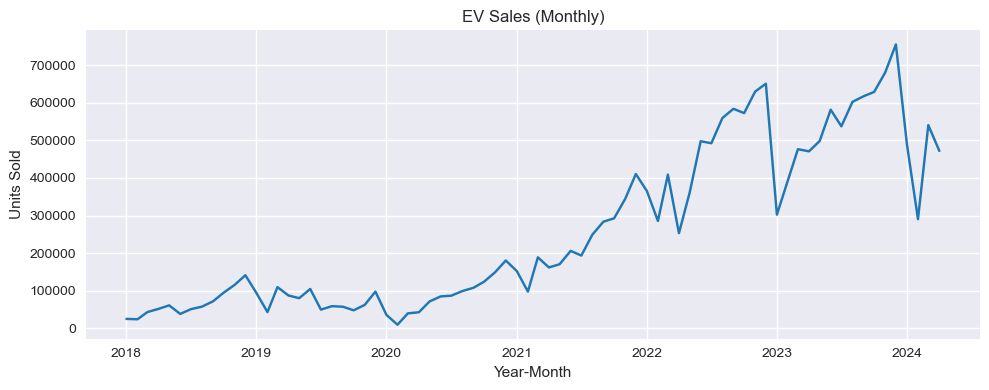

In [102]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["EV_Sales"], color="#1f77b4")
ax.set_title("EV Sales (Monthly)")
ax.set_ylabel("Units Sold")
ax.set_xlabel("Year-Month")
plt.tight_layout()
plt.show()

* **Primary Growth Trend:** Monthly EV sales show a strong upward trend. Sales were relatively low before 2020 and accelerated sharply from 2021 onward as adoption expanded.

* **Seasonality:** Sales typically dip at the beginning of the year (January-February, Lunar New Year effect) and recover toward mid-year, with peaks often in the final months.
* **Volatility:** As the market grows, the amplitude of month-to-month swings increases, indicating higher absolute variability in later years.

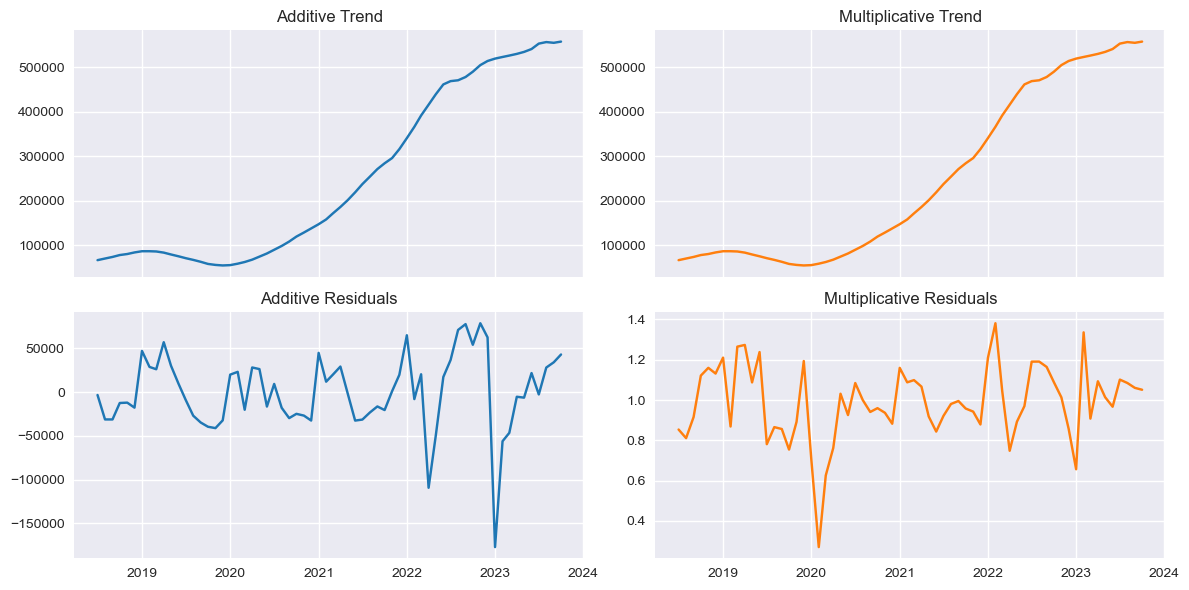

,additive_resid_std,multiplicative_resid_std,additive_resid_mean,multiplicative_resid_mean
0,42971.552021,0.187113,-133.525231,0.988576


In [103]:
# Compare additive vs. multiplicative decomposition
series_pos = monthly["EV_Sales"].replace(0, np.nan).dropna()
add_decomp = seasonal_decompose(series_pos, model="additive", period=12)
mul_decomp = seasonal_decompose(series_pos, model="multiplicative", period=12)

comparison_table = pd.DataFrame(
    {
        "additive_resid_std": [add_decomp.resid.dropna().std()],
        "multiplicative_resid_std": [mul_decomp.resid.dropna().std()],
        "additive_resid_mean": [add_decomp.resid.dropna().mean()],
        "multiplicative_resid_mean": [mul_decomp.resid.dropna().mean()],
    }
)

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
axes[0, 0].plot(add_decomp.trend, color="#1f77b4")
axes[0, 0].set_title("Additive Trend")
axes[0, 1].plot(mul_decomp.trend, color="#ff7f0e")
axes[0, 1].set_title("Multiplicative Trend")
axes[1, 0].plot(add_decomp.resid, color="#1f77b4")
axes[1, 0].set_title("Additive Residuals")
axes[1, 1].plot(mul_decomp.resid, color="#ff7f0e")
axes[1, 1].set_title("Multiplicative Residuals")

plt.tight_layout()
plt.show()

comparison_table

Note: std values are not directly comparable due to different units (absolute vs ratio)

#### Decomposition Results:

* **From a statistical perspective on the training set:** The Multiplicative model produced better results, with residuals having a mean closer to the ideal value (`0.988` compared to the target `1.0`). In addition, the residual fluctuation range (`std ~ 18.7%`) remained relatively stable over the years instead of expanding with the trend as in the Additive model.
* **From an economic perspective:** The Chinese EV market during 2018–2022 experienced rapid growth, suggesting that fluctuations were more proportional (multiplicative) rather than linearly additive.

#### Modeling Strategy:

Although the initial decomposition results temporarily favor the Multiplicative structure, this study **still chooses to retain the Additive model** for the next experimental stage.

The rationale and empirical evidence (based on actual forecasting performance and structural market changes during 2023–2024) will be further demonstrated and analyzed in detail in the **`modeling`** file using evaluation results from the **test set**.

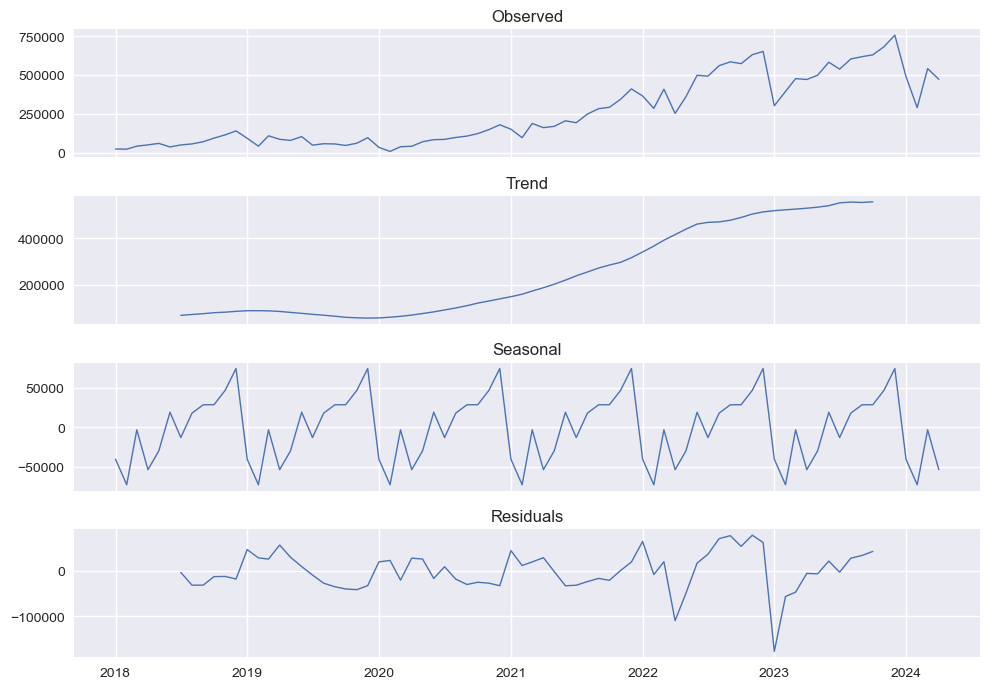

In [104]:
series = monthly["EV_Sales"].dropna()
decomp = seasonal_decompose(series, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)

axes[0].plot(series.index, series.values, "-", linewidth=1)
axes[0].set_title("Observed")

axes[1].plot(decomp.trend.index, decomp.trend.values, "-", linewidth=1)
axes[1].set_title("Trend")

axes[2].plot(decomp.seasonal.index, decomp.seasonal.values, "-", linewidth=1)
axes[2].set_title("Seasonal")

axes[3].plot(decomp.resid.index, decomp.resid.values, "-", linewidth=1)
axes[3].set_title("Residuals")

plt.tight_layout()
plt.show()

* **Observed:** EV sales generally increased over time, with clear yearly cycles and stronger fluctuations after 2022.

* **Trend:**

  * **2018–2020:** Slow growth.
  * **2021–2022:** Rapid market expansion.
  * **2023–2024:** Growth slowed and became more stable.

* **Seasonal:** A clear 12-month seasonal pattern exists, with sales dropping in January–February and peaking at year-end. Seasonal effects range from `-75,000` to `75,000` vehicles.

* **Residuals:**

  * **2018–2021:** Stable residuals around `0`.
  * **2022–2023:** Larger fluctuations appeared, including a sharp decline in early 2023 (`~ -175,000`), reflecting the impact of subsidy cuts and a structural break.

In [105]:
print("Check Outliers in Residuals:")

residuals = decomp.resid.dropna()

mean_resid = residuals.mean()
std_resid = residuals.std()
lower_bound = mean_resid - 3 * std_resid
upper_bound = mean_resid + 3 * std_resid

time_series_outliers = residuals[(residuals < lower_bound) | (residuals > upper_bound)]

if len(time_series_outliers) == 0:
    print("-> Result: NO macroeconomic shocks were detected. The residuals fluctuated stably within the 3-sigma threshold")
    print("-> Data is clean and ready for SARIMA modeling")
else:
    print(f"-> Result: {len(time_series_outliers)} months with abnormal fluctuations detected:")
    print(time_series_outliers)

Check Outliers in Residuals:
-> Result: 1 months with abnormal fluctuations detected:
year_month
2023-01-01   -176988.958565
Freq: MS, Name: resid, dtype: float64


**January 2023 (Post-Subsidy "Hangover" Effect):**
Following the complete phase-out of national EV purchase subsidies on December 31, 2022, the market experienced a severe demand slump. Because consumers had aggressively pulled forward their purchases to late 2022 to capitalize on the expiring subsidies, sales in early 2023 plummeted far below expected trend and seasonal levels. This manifests as a sharp negative shock in the residuals for January 2023.

Although one outlier month was detected in the residuals, we did not manually adjust or remove it because it reflects a real market shock rather than a data error. After decomposing the series, the 3-sigma check is used only to identify unusually large deviations from the underlying trend and seasonality. In this case, the abnormal fluctuation is associated with an actual policy-driven demand shock in the EV market, so keeping it preserves the structural change in the data. Removing it would discard meaningful information and could bias the subsequent SARIMA modeling.

### Log vs No-Log (ADF Check)

We compare the original series with a log-transformed version and check stationarity using the ADF test on levels and first differences.

In [106]:
series_no_log = monthly["EV_Sales"].astype(float)
series_log = np.log1p(series_no_log)


def adf_pvalue(series):
    result = adfuller(series.dropna(), autolag="AIC")
    return result[1]


adf_table = pd.DataFrame(
    [
        {
            "transform": "no_log",
            "level_pvalue": adf_pvalue(series_no_log),
            "diff1_pvalue": adf_pvalue(series_no_log.diff(1)),
        },
        {
            "transform": "log1p",
            "level_pvalue": adf_pvalue(series_log),
            "diff1_pvalue": adf_pvalue(series_log.diff(1)),
        },
    ]
).sort_values("transform").reset_index(drop=True)

adf_table

,transform,level_pvalue,diff1_pvalue
0,log1p,0.896490,0.123900
1,no_log,0.957891,0.607678


Although the log transformation reduced the p-value to 0.1239, both first-difference approaches still failed to achieve full stationarity (p-value > 0.05) due to the strong 12-month seasonal pattern. Therefore, this study decided to retain the original non-log-transformed series in order to preserve the interpretability of the forecast units. At the same time, it is hypothesized that this non-stationarity will be effectively addressed later through the seasonal differencing component of the SARIMA model. (Prove that no-log is better than log in the modeling section)

In [107]:
out_path = Path("../Data/Processed/ev_sales_monthly.csv")
monthly.to_csv(out_path)

out_path

WindowsPath('../Data/Processed/ev_sales_monthly.csv')